# Graph Attention Networks (GAT) — PPI Reimplementation
**Paper:** Veličković et al., "Graph Attention Networks" (ICLR 2018)  
**Task:** Inductive node classification on PPI (Table 3)  
**Target:** GAT ≈ 0.973 micro-F1, Const-GAT ≈ 0.934 micro-F1

In [ ]:
# Install dependencies
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.1 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import PPI
from torch_geometric.loader import DataLoader
from sklearn.metrics import f1_score
import numpy as np
import copy
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load PPI Dataset
- 20 graphs for training, 2 for validation, 2 for test
- 50 input features per node, 121 labels (multi-label)
- Batch size = 2 graphs (as in the paper)

In [ ]:
train_dataset = PPI(root='data/PPI', split='train')
val_dataset = PPI(root='data/PPI', split='val')
test_dataset = PPI(root='data/PPI', split='test')

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

print(f"Train graphs: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Node features: {train_dataset.num_features}, Labels: {train_dataset.num_classes}")
print(f"Example graph: {train_dataset[0]}")

Extracting data/PPI/ppi.zip
Processing...


Train graphs: 20, Val: 2, Test: 2
Node features: 50, Labels: 121
Example graph: Data(x=[1767, 50], edge_index=[2, 32318], y=[1767, 121])


Done!


## 2. GAT Layer (from scratch)

Each layer computes:
1. Linear transform: $Wh_i$ for all nodes
2. Attention scores: $e_{ij} = \text{LeakyReLU}(\mathbf{a}^T [Wh_i \| Wh_j])$
3. Normalize via softmax over neighbors
4. Weighted sum of transformed neighbor features

Multi-head: K independent heads, concatenated (hidden layers) or averaged (output layer).

In [ ]:
class GATLayer(nn.Module):
    """Single-head graph attention layer."""

    def __init__(self, in_features, out_features, is_const=False):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=True)
        self.a_src = nn.Parameter(torch.empty(1, out_features))
        self.a_dst = nn.Parameter(torch.empty(1, out_features))
        self.is_const = is_const
        self.leaky_relu = nn.LeakyReLU(0.2)

        nn.init.xavier_uniform_(self.W.weight)
        nn.init.zeros_(self.W.bias)
        nn.init.xavier_uniform_(self.a_src.view(1, -1))
        nn.init.xavier_uniform_(self.a_dst.view(1, -1))

    def forward(self, x, edge_index):
        N = x.size(0)
        Wh = self.W(x)

        src, dst = edge_index

        if self.is_const:
            out = torch.zeros(N, Wh.size(1), device=x.device)
            out.scatter_add_(0, dst.unsqueeze(1).expand_as(Wh[src]), Wh[src])
            ones = torch.ones(src.size(0), device=x.device)
            deg = torch.zeros(N, device=x.device)
            deg.scatter_add_(0, dst, ones)
            deg = deg.clamp(min=1)
            out = out / deg.unsqueeze(1)
            return out

        score_src = (Wh * self.a_src).sum(dim=1)
        score_dst = (Wh * self.a_dst).sum(dim=1)

        e = score_src[src] + score_dst[dst]
        e = self.leaky_relu(e)

        e_max = torch.full((N,), float('-inf'), device=x.device)
        e_max.scatter_reduce_(0, dst, e, reduce='amax', include_self=False)
        e_exp = torch.exp(e - e_max[dst])

        e_sum = torch.zeros(N, device=x.device)
        e_sum.scatter_add_(0, dst, e_exp)
        alpha = e_exp / (e_sum[dst] + 1e-16)

        out = torch.zeros(N, Wh.size(1), device=x.device)
        out.scatter_add_(0, dst.unsqueeze(1).expand_as(Wh[src]), Wh[src] * alpha.unsqueeze(1))

        return out


class MultiHeadGATLayer(nn.Module):
    """Multi-head GAT: K independent heads, concatenated or averaged."""

    def __init__(self, in_features, out_features, num_heads, concat=True, is_const=False):
        super().__init__()
        self.heads = nn.ModuleList([
            GATLayer(in_features, out_features, is_const=is_const)
            for _ in range(num_heads)
        ])
        self.concat = concat

    def forward(self, x, edge_index):
        head_outs = [head(x, edge_index) for head in self.heads]
        if self.concat:
            return torch.cat(head_outs, dim=1)
        else:
            return torch.stack(head_outs, dim=0).mean(dim=0)

## 3. GAT Model for PPI

Architecture (from paper, Section 3.2 / Appendix A):
- **Layer 1:** 4 heads × 256 features = 1024, ELU activation
- **Layer 2:** 4 heads × 256 features = 1024, ELU activation + skip connection from Layer 1
- **Layer 3:** 6 heads × 121 features, averaged, sigmoid

No dropout, no L2 regularization (paper says these are omitted for PPI due to larger training set).

In [ ]:
from torch_geometric.utils import add_self_loops

class GATForPPI(nn.Module):
    def __init__(self, in_features=50, hidden=256, out_features=121,
                 heads_hidden=4, heads_out=6, is_const=False):
        super().__init__()
        self.layer1 = MultiHeadGATLayer(in_features, hidden, heads_hidden,
                                        concat=True, is_const=is_const)
        self.layer2 = MultiHeadGATLayer(hidden * heads_hidden, hidden, heads_hidden,
                                        concat=True, is_const=is_const)
        self.layer3 = MultiHeadGATLayer(hidden * heads_hidden, out_features, heads_out,
                                        concat=False, is_const=is_const)

    def forward(self, x, edge_index):
        # Add self-loops so each node attends to itself too
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        h1 = self.layer1(x, edge_index)
        h1 = F.elu(h1)

        h2 = self.layer2(h1, edge_index)
        h2 = F.elu(h2) + h1  # skip connection

        out = self.layer3(h2, edge_index)
        return out

## 4. Training & Evaluation

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    num_nodes = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item() * data.x.size(0)
        num_nodes += data.x.size(0)
    return total_loss / num_nodes


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ys, preds = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        pred = (out > 0).float()
        ys.append(data.y.cpu().numpy())
        preds.append(pred.cpu().numpy())
    y = np.concatenate(ys, axis=0)
    pred = np.concatenate(preds, axis=0)
    return f1_score(y, pred, average='micro')

In [ ]:
def run_experiment(is_const=False, num_runs=10, max_epochs=1000, patience=100, lr=0.005):
    """Run full training with early stopping, repeated num_runs times."""
    label = "Const-GAT" if is_const else "GAT"
    results = []

    for run in range(num_runs):
        t0 = time.time()

        model = GATForPPI(is_const=is_const).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.BCEWithLogitsLoss()

        num_params = sum(p.numel() for p in model.parameters())
        print(f"\n{'='*60}")
        print(f"[{label}] Run {run+1}/{num_runs} — {num_params:,} parameters")
        print(f"{'='*60}")

        best_val_f1 = 0.0
        best_model_state = None
        epochs_no_improve = 0

        for epoch in range(1, max_epochs + 1):
            loss = train_epoch(model, train_loader, optimizer, criterion)
            val_f1 = evaluate(model, val_loader)

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
                marker = " *"
            else:
                epochs_no_improve += 1
                marker = ""

            if epoch % 5 == 0 or epoch == 1:
                elapsed = time.time() - t0
                print(f"  Epoch {epoch:4d} | loss={loss:.4f} | val_f1={val_f1:.4f} | "
                      f"best={best_val_f1:.4f} | patience={epochs_no_improve}/{patience} | "
                      f"{elapsed:.0f}s{marker}")

            if epochs_no_improve >= patience:
                print(f"  >> Early stopping at epoch {epoch}")
                break

        # Load best model and evaluate on test set
        model.load_state_dict(best_model_state)
        test_f1 = evaluate(model, test_loader)
        elapsed = time.time() - t0
        results.append(test_f1)
        print(f"\n  >> Test F1: {test_f1:.4f} ({elapsed:.0f}s total)")

        # Save results after each run in case of disconnect
        np.save(f'/content/{label}_results_so_far.npy', np.array(results))
        print(f"  >> Results saved to /content/{label}_results_so_far.npy")

    mean_f1 = np.mean(results)
    std_f1 = np.std(results)
    print(f"\n{'='*60}")
    print(f"{label} — {num_runs} runs: {mean_f1:.4f} ± {std_f1:.4f}")
    print(f"{'='*60}\n")
    return results

In [ ]:
# Check if PPI already has self-loops
data = train_dataset[0]
src, dst = data.edge_index
self_loops = (src == dst).sum().item()
print(f"Nodes: {data.x.size(0)}, Edges: {data.edge_index.size(1)}, Self-loops already present: {self_loops}")

Nodes: 1767, Edges: 32318, Self-loops already present: 0


## 5. Run GAT (target: 0.973 ± 0.002)

In [ ]:
gat_results = run_experiment(is_const=False, num_runs=10)


[GAT] Run 1/10 — 1,851,522 parameters
  Epoch    1 | loss=0.6859 | val_f1=0.4563 | best=0.4563 | patience=0/100 | 2s *
  Epoch    5 | loss=0.4973 | val_f1=0.5387 | best=0.5387 | patience=0/100 | 8s *
  Epoch   10 | loss=0.4512 | val_f1=0.6145 | best=0.6145 | patience=0/100 | 16s *
  Epoch   15 | loss=0.4174 | val_f1=0.6042 | best=0.6443 | patience=2/100 | 24s
  Epoch   20 | loss=0.3848 | val_f1=0.6873 | best=0.6873 | patience=0/100 | 32s *
  Epoch   25 | loss=0.3487 | val_f1=0.7062 | best=0.7062 | patience=0/100 | 40s *
  Epoch   30 | loss=0.3202 | val_f1=0.7181 | best=0.7256 | patience=4/100 | 48s
  Epoch   35 | loss=0.2920 | val_f1=0.7572 | best=0.7582 | patience=1/100 | 56s
  Epoch   40 | loss=0.2630 | val_f1=0.7852 | best=0.7852 | patience=0/100 | 64s *
  Epoch   45 | loss=0.2488 | val_f1=0.7912 | best=0.7932 | patience=3/100 | 72s
  Epoch   50 | loss=0.2157 | val_f1=0.8114 | best=0.8133 | patience=1/100 | 80s
  Epoch   55 | loss=0.2151 | val_f1=0.8185 | best=0.8185 | patience=0/1

# Trying GAT and Const GAT with per head Residual Connections

## 6. Run Const-GAT (target: 0.934 ± 0.006)

In [ ]:
class ResidualGATLayer(nn.Module):
    """Single-head GAT layer with per-head residual connection."""

    def __init__(self, in_features, out_features, residual=False):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=True)
        self.a_src = nn.Parameter(torch.empty(1, out_features))
        self.a_dst = nn.Parameter(torch.empty(1, out_features))
        self.leaky_relu = nn.LeakyReLU(0.2)

        self.residual = residual
        if residual:
            if in_features != out_features:
                self.res_proj = nn.Linear(in_features, out_features, bias=False)
            else:
                self.res_proj = None

        nn.init.xavier_uniform_(self.W.weight)
        nn.init.zeros_(self.W.bias)
        nn.init.xavier_uniform_(self.a_src.view(1, -1))
        nn.init.xavier_uniform_(self.a_dst.view(1, -1))

    def forward(self, x, edge_index):
        N = x.size(0)
        Wh = self.W(x)
        src, dst = edge_index

        score_src = (Wh * self.a_src).sum(dim=1)
        score_dst = (Wh * self.a_dst).sum(dim=1)

        e = score_src[src] + score_dst[dst]
        e = self.leaky_relu(e)

        e_max = torch.full((N,), float('-inf'), device=x.device)
        e_max.scatter_reduce_(0, dst, e, reduce='amax', include_self=False)
        e_exp = torch.exp(e - e_max[dst])

        e_sum = torch.zeros(N, device=x.device)
        e_sum.scatter_add_(0, dst, e_exp)
        alpha = e_exp / (e_sum[dst] + 1e-16)

        out = torch.zeros(N, Wh.size(1), device=x.device)
        out.scatter_add_(0, dst.unsqueeze(1).expand_as(Wh[src]), Wh[src] * alpha.unsqueeze(1))

        if self.residual:
            if self.res_proj is not None:
                out = out + self.res_proj(x)
            else:
                out = out + x

        return out


class MultiHeadResidualGATLayer(nn.Module):
    def __init__(self, in_features, out_features, num_heads, concat=True, residual=False):
        super().__init__()
        self.heads = nn.ModuleList([
            ResidualGATLayer(in_features, out_features, residual=residual)
            for _ in range(num_heads)
        ])
        self.concat = concat

    def forward(self, x, edge_index):
        head_outs = [head(x, edge_index) for head in self.heads]
        if self.concat:
            return torch.cat(head_outs, dim=1)
        else:
            return torch.stack(head_outs, dim=0).mean(dim=0)


class ResidualGATForPPI(nn.Module):
    def __init__(self, in_features=50, hidden=256, out_features=121,
                 heads_hidden=4, heads_out=6):
        super().__init__()
        self.layer1 = MultiHeadResidualGATLayer(in_features, hidden, heads_hidden,
                                                 concat=True, residual=True)
        self.layer2 = MultiHeadResidualGATLayer(hidden * heads_hidden, hidden, heads_hidden,
                                                 concat=True, residual=True)
        self.layer3 = MultiHeadResidualGATLayer(hidden * heads_hidden, out_features, heads_out,
                                                 concat=False, residual=False)

    def forward(self, x, edge_index):
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        h1 = self.layer1(x, edge_index)
        h1 = F.elu(h1)

        h2 = self.layer2(h1, edge_index)
        h2 = F.elu(h2)

        out = self.layer3(h2, edge_index)
        return out


class ConstGATLayer(nn.Module):
    """Single-head constant attention (mean aggregation) with per-head residual."""

    def __init__(self, in_features, out_features, residual=False):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=True)

        self.residual = residual
        if residual:
            if in_features != out_features:
                self.res_proj = nn.Linear(in_features, out_features, bias=False)
            else:
                self.res_proj = None

        nn.init.xavier_uniform_(self.W.weight)
        nn.init.zeros_(self.W.bias)

    def forward(self, x, edge_index):
        N = x.size(0)
        Wh = self.W(x)
        src, dst = edge_index

        out = torch.zeros(N, Wh.size(1), device=x.device)
        out.scatter_add_(0, dst.unsqueeze(1).expand_as(Wh[src]), Wh[src])
        ones = torch.ones(src.size(0), device=x.device)
        deg = torch.zeros(N, device=x.device)
        deg.scatter_add_(0, dst, ones)
        deg = deg.clamp(min=1)
        out = out / deg.unsqueeze(1)

        if self.residual:
            if self.res_proj is not None:
                out = out + self.res_proj(x)
            else:
                out = out + x

        return out


class MultiHeadConstGATLayer(nn.Module):
    def __init__(self, in_features, out_features, num_heads, concat=True, residual=False):
        super().__init__()
        self.heads = nn.ModuleList([
            ConstGATLayer(in_features, out_features, residual=residual)
            for _ in range(num_heads)
        ])
        self.concat = concat

    def forward(self, x, edge_index):
        head_outs = [head(x, edge_index) for head in self.heads]
        if self.concat:
            return torch.cat(head_outs, dim=1)
        else:
            return torch.stack(head_outs, dim=0).mean(dim=0)


class ConstGATForPPI(nn.Module):
    def __init__(self, in_features=50, hidden=256, out_features=121,
                 heads_hidden=4, heads_out=6):
        super().__init__()
        self.layer1 = MultiHeadConstGATLayer(in_features, hidden, heads_hidden,
                                              concat=True, residual=True)
        self.layer2 = MultiHeadConstGATLayer(hidden * heads_hidden, hidden, heads_hidden,
                                              concat=True, residual=True)
        self.layer3 = MultiHeadConstGATLayer(hidden * heads_hidden, out_features, heads_out,
                                              concat=False, residual=False)

    def forward(self, x, edge_index):
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        h1 = self.layer1(x, edge_index)
        h1 = F.elu(h1)

        h2 = self.layer2(h1, edge_index)
        h2 = F.elu(h2)

        out = self.layer3(h2, edge_index)
        return out

In [ ]:
def run_const_experiment(model_type='const', num_runs=10, max_epochs=1000, patience=100, lr=0.005):
    """Run GAT or Const-GAT with per-head residuals."""
    if model_type == 'const':
        label = "Const-GAT-Res"
    else:
        label = "GAT-Res"
    results = []

    for run in range(num_runs):
        t0 = time.time()

        if model_type == 'const':
            model = ConstGATForPPI().to(device)
        else:
            model = ResidualGATForPPI().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.BCEWithLogitsLoss()

        num_params = sum(p.numel() for p in model.parameters())
        print(f"\n{'='*60}")
        print(f"[{label}] Run {run+1}/{num_runs} — {num_params:,} parameters")
        print(f"{'='*60}")

        best_val_f1 = 0.0
        best_model_state = None
        epochs_no_improve = 0

        for epoch in range(1, max_epochs + 1):
            loss = train_epoch(model, train_loader, optimizer, criterion)
            val_f1 = evaluate(model, val_loader)

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_model_state = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
                marker = " *"
            else:
                epochs_no_improve += 1
                marker = ""

            if epoch % 5 == 0 or epoch == 1:
                elapsed = time.time() - t0
                print(f"  Epoch {epoch:4d} | loss={loss:.4f} | val_f1={val_f1:.4f} | "
                      f"best={best_val_f1:.4f} | patience={epochs_no_improve}/{patience} | "
                      f"{elapsed:.0f}s{marker}")

            if epochs_no_improve >= patience:
                print(f"  >> Early stopping at epoch {epoch}")
                break

        model.load_state_dict(best_model_state)
        test_f1 = evaluate(model, test_loader)
        elapsed = time.time() - t0
        results.append(test_f1)
        print(f"\n  >> Test F1: {test_f1:.4f} ({elapsed:.0f}s total)")

        np.save(f'/content/{label}_results_so_far.npy', np.array(results))
        print(f"  >> Results saved to /content/{label}_results_so_far.npy")

    mean_f1 = np.mean(results)
    std_f1 = np.std(results)
    print(f"\n{'='*60}")
    print(f"{label} — {num_runs} runs: {mean_f1:.4f} ± {std_f1:.4f}")
    print(f"{'='*60}\n")
    return results

In [ ]:
gat_res_results = run_const_experiment(model_type='gat', num_runs=10)


[GAT-Res] Run 1/10 — 2,951,298 parameters
  Epoch    1 | loss=0.7181 | val_f1=0.4070 | best=0.4070 | patience=0/100 | 3s *
  Epoch    5 | loss=0.4765 | val_f1=0.5692 | best=0.5692 | patience=0/100 | 9s *
  Epoch   10 | loss=0.3861 | val_f1=0.6783 | best=0.6783 | patience=0/100 | 18s *
  Epoch   15 | loss=0.2984 | val_f1=0.7623 | best=0.7623 | patience=0/100 | 26s *
  Epoch   20 | loss=0.2390 | val_f1=0.7912 | best=0.8013 | patience=1/100 | 35s
  Epoch   25 | loss=0.1847 | val_f1=0.8282 | best=0.8479 | patience=1/100 | 44s
  Epoch   30 | loss=0.1664 | val_f1=0.8687 | best=0.8687 | patience=0/100 | 54s *
  Epoch   35 | loss=0.1215 | val_f1=0.8934 | best=0.8934 | patience=0/100 | 63s *
  Epoch   40 | loss=0.1103 | val_f1=0.8986 | best=0.8986 | patience=0/100 | 72s *
  Epoch   45 | loss=0.0956 | val_f1=0.9098 | best=0.9098 | patience=0/100 | 81s *
  Epoch   50 | loss=0.0797 | val_f1=0.9171 | best=0.9171 | patience=0/100 | 89s *
  Epoch   55 | loss=0.0826 | val_f1=0.9151 | best=0.9202 | pa

In [ ]:
const_gat_results = run_const_experiment(num_runs=10)


[Const-GAT-Res] Run 1/10 — 2,945,750 parameters
  Epoch    1 | loss=0.6334 | val_f1=0.4323 | best=0.4323 | patience=0/100 | 1s *
  Epoch    5 | loss=0.4954 | val_f1=0.5064 | best=0.5064 | patience=0/100 | 5s *
  Epoch   10 | loss=0.4575 | val_f1=0.5005 | best=0.5766 | patience=2/100 | 10s
  Epoch   15 | loss=0.4266 | val_f1=0.6189 | best=0.6189 | patience=0/100 | 15s *
  Epoch   20 | loss=0.3896 | val_f1=0.6092 | best=0.6472 | patience=4/100 | 20s
  Epoch   25 | loss=0.3596 | val_f1=0.6719 | best=0.6799 | patience=2/100 | 25s
  Epoch   30 | loss=0.3462 | val_f1=0.7151 | best=0.7151 | patience=0/100 | 30s *
  Epoch   35 | loss=0.3268 | val_f1=0.7284 | best=0.7284 | patience=0/100 | 35s *
  Epoch   40 | loss=0.3018 | val_f1=0.7540 | best=0.7540 | patience=0/100 | 40s *
  Epoch   45 | loss=0.3205 | val_f1=0.7280 | best=0.7564 | patience=3/100 | 44s
  Epoch   50 | loss=0.2807 | val_f1=0.7536 | best=0.7564 | patience=8/100 | 49s
  Epoch   55 | loss=0.2704 | val_f1=0.7744 | best=0.7778 | pa

## 7. Summary & Comparison

In [21]:
import os

if os.path.exists('/content/GAT-Res_results_so_far.npy'):
    gat_res_results = np.load('/content/GAT-Res_results_so_far.npy').tolist()
if os.path.exists('/content/Const-GAT-Res_results_so_far.npy'):
    const_gat_res_results = np.load('/content/Const-GAT-Res_results_so_far.npy').tolist()

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"{'Model':<15} {'Ours':<20} {'Paper':<20}")
print("-" * 60)
print(f"{'GAT':<15} {np.mean(gat_res_results):.4f} ± {np.std(gat_res_results):.4f}    0.973 ± 0.002")
print(f"{'Const-GAT':<15} {np.mean(const_gat_res_results):.4f} ± {np.std(const_gat_res_results):.4f}    0.934 ± 0.006")
print("-" * 60)
gap_ours = np.mean(gat_res_results) - np.mean(const_gat_res_results)
print(f"Attention gap:  {gap_ours:.4f} (paper: ~0.039)")
print(f"\nWithin ±0.01 of paper?")
print(f"  GAT:       {abs(np.mean(gat_res_results) - 0.973) < 0.01}")
print(f"  Const-GAT: {abs(np.mean(const_gat_res_results) - 0.934) < 0.01}")

RESULTS SUMMARY
Model           Ours                 Paper               
------------------------------------------------------------
GAT             0.9719 ± 0.0024    0.973 ± 0.002
Const-GAT       0.9574 ± 0.0004    0.934 ± 0.006
------------------------------------------------------------
Attention gap:  0.0145 (paper: ~0.039)

Within ±0.01 of paper?
  GAT:       True
  Const-GAT: False


Parsed rows: 3564
Runs found:
model
Const-GAT-Res    10
GAT-Res          10
Name: run, dtype: int64

Test F1 summary:


,mean,std,min,max
model,,,,
Const-GAT-Res,0.9574,0.0004,0.9566,0.9578
GAT-Res,0.9719,0.0025,0.9675,0.9757


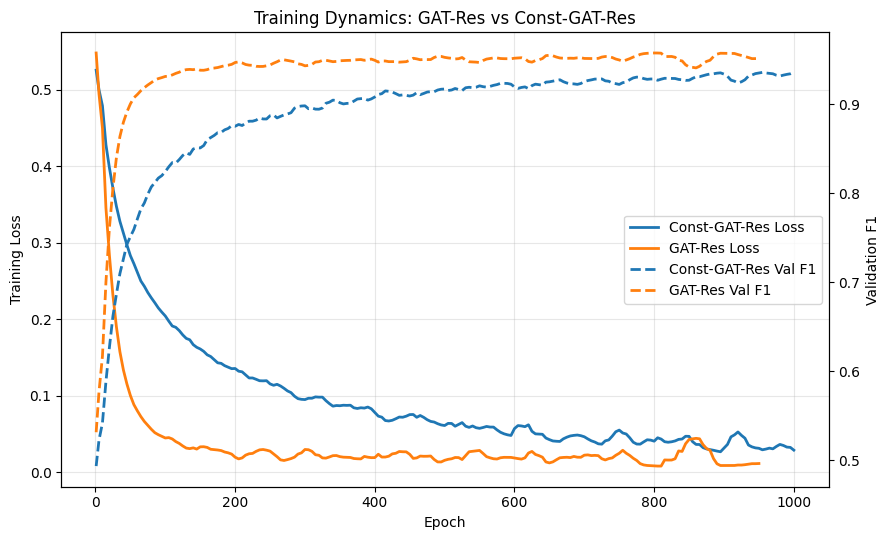

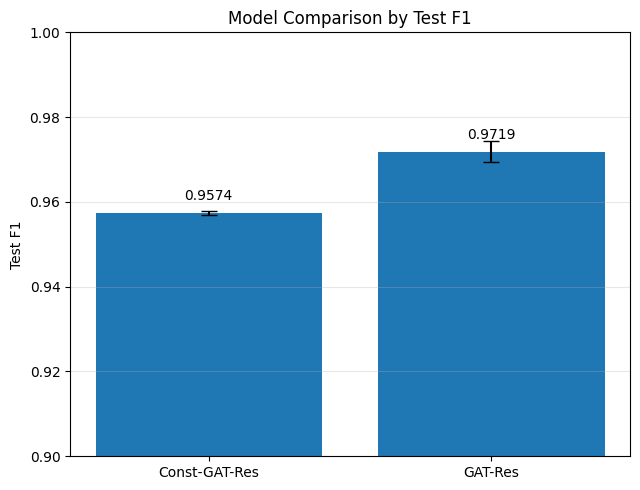

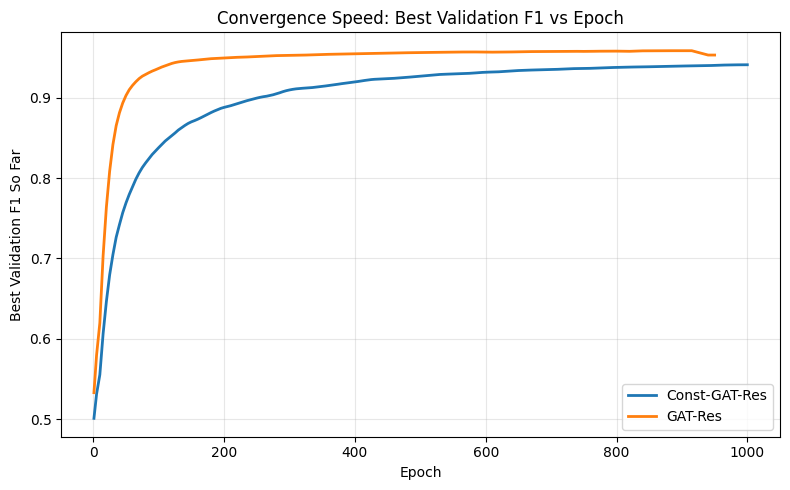

/tmp/ipykernel_1027/4183405507.py:178: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Const-GAT-Res", "GAT-Res"])


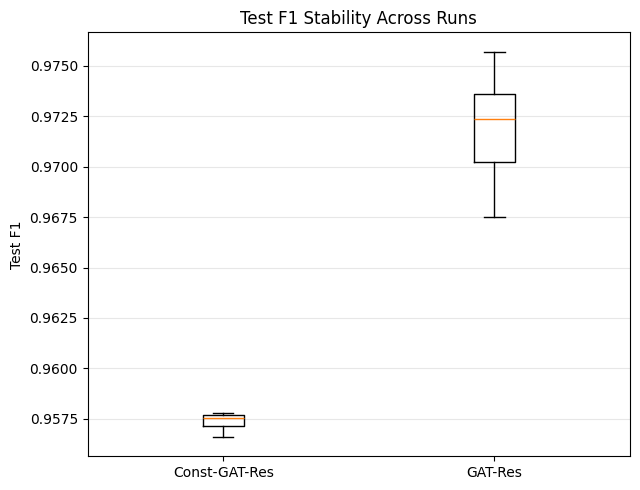

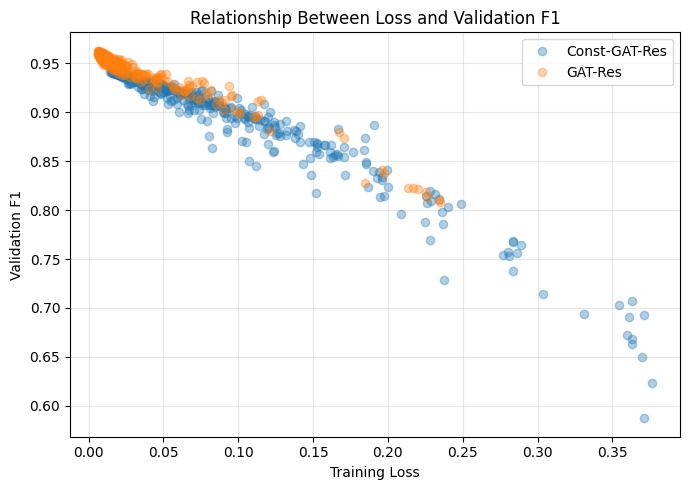

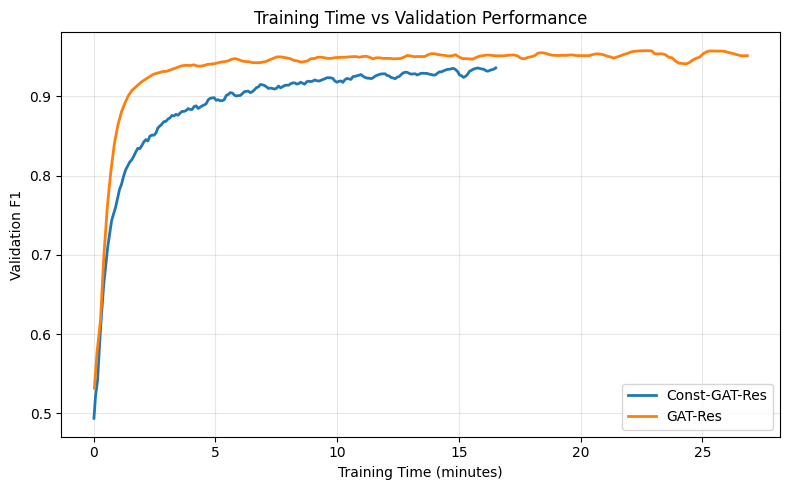

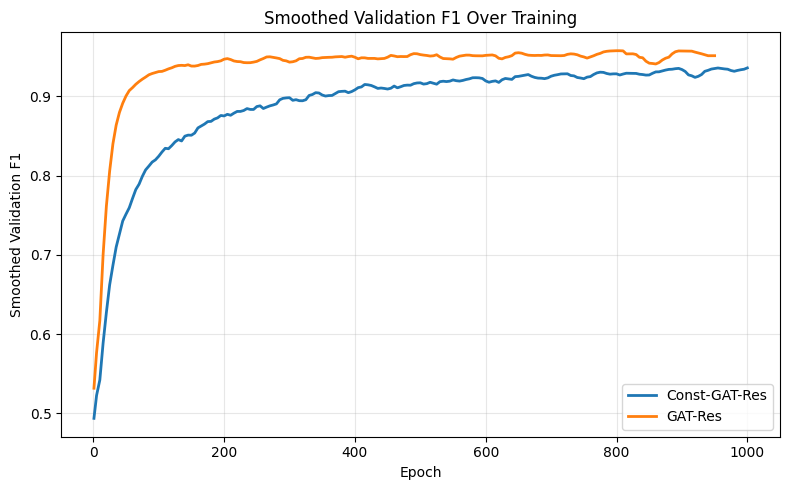

Saved all graphs to: /content/poster_graphs


In [17]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt

LOG_FILES = {
    "Const-GAT-Res": "/content/ConstGAT_F1_Loss.rtf",
    "GAT-Res": "/content/GAT_F1_LOSS.rtf",
}

OUT_DIR = "/content/poster_graphs"
os.makedirs(OUT_DIR, exist_ok=True)

def parse_training_log(path, model_name):
    with open(path, "r", errors="ignore") as f:
        text = f.read()

    run_headers = list(re.finditer(
        r"\[" + re.escape(model_name) + r"\]\s+Run\s+(\d+)/\d+",
        text
    ))

    epoch_pattern = re.compile(
        r"Epoch\s+(\d+)\s+\|\s+loss=([0-9.]+)\s+\|\s+val_f1=([0-9.]+)\s+\|\s+best=([0-9.]+).*?\|\s+(\d+)s"
    )

    rows = []

    for idx, header in enumerate(run_headers):
        run_id = int(header.group(1))
        start = header.end()
        end = run_headers[idx + 1].start() if idx + 1 < len(run_headers) else len(text)
        run_text = text[start:end]

        for ep, loss, val_f1, best, seconds in epoch_pattern.findall(run_text):
            rows.append({
                "model": model_name,
                "run": run_id,
                "epoch": int(ep),
                "loss": float(loss),
                "val_f1": float(val_f1),
                "best_f1": float(best),
                "seconds": int(seconds),
            })

    return pd.DataFrame(rows)

def extract_test_f1_from_log(path, model_name):
    with open(path, "r", errors="ignore") as f:
        text = f.read()

    vals = re.findall(r">>\s*Test F1:\s*([0-9.]+)", text)

    return pd.DataFrame({
        "model": model_name,
        "run": list(range(1, len(vals) + 1)),
        "test_f1": [float(v) for v in vals],
    })

logs = pd.concat(
    [parse_training_log(path, model) for model, path in LOG_FILES.items()],
    ignore_index=True
)

test_df = pd.concat(
    [extract_test_f1_from_log(path, model) for model, path in LOG_FILES.items()],
    ignore_index=True
)

print("Parsed rows:", len(logs))
print("Runs found:")
print(logs.groupby("model")["run"].nunique())

print("\nTest F1 summary:")
display(test_df.groupby("model")["test_f1"].agg(["mean", "std", "min", "max"]).round(4))

curve_summary = (
    logs.groupby(["model", "epoch"])
    .agg(
        loss_mean=("loss", "mean"),
        val_f1_mean=("val_f1", "mean"),
        best_f1_mean=("best_f1", "mean"),
        seconds_mean=("seconds", "mean"),
    )
    .reset_index()
)

curve_summary["loss_smooth"] = curve_summary.groupby("model")["loss_mean"].transform(
    lambda x: x.rolling(window=5, min_periods=1, center=True).mean()
)

curve_summary["val_f1_smooth"] = curve_summary.groupby("model")["val_f1_mean"].transform(
    lambda x: x.rolling(window=5, min_periods=1, center=True).mean()
)

curve_summary["best_f1_smooth"] = curve_summary.groupby("model")["best_f1_mean"].transform(
    lambda x: x.rolling(window=5, min_periods=1, center=True).mean()
)

colors = {
    "Const-GAT-Res": "tab:blue",
    "GAT-Res": "tab:orange",
}

# 1. Combined Training Dynamics
plt.figure(figsize=(9, 5.5))
ax1 = plt.gca()
ax2 = ax1.twinx()

for model in ["Const-GAT-Res", "GAT-Res"]:
    sub = curve_summary[curve_summary["model"] == model]

    ax1.plot(sub["epoch"], sub["loss_smooth"], "-", linewidth=2,
             color=colors[model], label=f"{model} Loss")

    ax2.plot(sub["epoch"], sub["val_f1_smooth"], "--", linewidth=2,
             color=colors[model], label=f"{model} Val F1")

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax2.set_ylabel("Validation F1")
plt.title("Training Dynamics: GAT-Res vs Const-GAT-Res")
ax1.grid(True, alpha=0.3)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc="center right")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/combined_training_dynamics.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Test F1 Bar Chart
test_summary = test_df.groupby("model").agg(
    mean_test_f1=("test_f1", "mean"),
    std_test_f1=("test_f1", "std")
).reset_index()

plt.figure(figsize=(6.5, 5))
plt.bar(test_summary["model"], test_summary["mean_test_f1"],
        yerr=test_summary["std_test_f1"], capsize=6)
plt.ylabel("Test F1")
plt.title("Model Comparison by Test F1")
plt.ylim(0.90, 1.00)
plt.grid(axis="y", alpha=0.3)

for i, row in test_summary.iterrows():
    plt.text(i, row["mean_test_f1"] + 0.003,
             f"{row['mean_test_f1']:.4f}", ha="center")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/model_test_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Best Validation F1 vs Epoch
plt.figure(figsize=(8, 5))

for model in ["Const-GAT-Res", "GAT-Res"]:
    sub = curve_summary[curve_summary["model"] == model]
    plt.plot(sub["epoch"], sub["best_f1_smooth"], linewidth=2,
             color=colors[model], label=model)

plt.xlabel("Epoch")
plt.ylabel("Best Validation F1 So Far")
plt.title("Convergence Speed: Best Validation F1 vs Epoch")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/best_f1_vs_epoch.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Test F1 Stability Across Runs
plt.figure(figsize=(6.5, 5))
data = [
    test_df[test_df["model"] == "Const-GAT-Res"]["test_f1"],
    test_df[test_df["model"] == "GAT-Res"]["test_f1"],
]
plt.boxplot(data, labels=["Const-GAT-Res", "GAT-Res"])
plt.ylabel("Test F1")
plt.title("Test F1 Stability Across Runs")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/test_f1_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Loss vs Validation F1
plt.figure(figsize=(7, 5))

for model in ["Const-GAT-Res", "GAT-Res"]:
    sub = logs[(logs["model"] == model) & (logs["epoch"] % 25 == 0)]
    plt.plot(sub["loss"], sub["val_f1"], marker="o", linestyle="",
             alpha=0.35, color=colors[model], label=model)

plt.xlabel("Training Loss")
plt.ylabel("Validation F1")
plt.title("Relationship Between Loss and Validation F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/loss_vs_valf1.png", dpi=300, bbox_inches="tight")
plt.show()

# 6. Training Time vs Validation F1
plt.figure(figsize=(8, 5))

for model in ["Const-GAT-Res", "GAT-Res"]:
    sub = curve_summary[curve_summary["model"] == model]
    plt.plot(sub["seconds_mean"] / 60, sub["val_f1_smooth"],
             linewidth=2, color=colors[model], label=model)

plt.xlabel("Training Time (minutes)")
plt.ylabel("Validation F1")
plt.title("Training Time vs Validation Performance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/time_vs_valf1.png", dpi=300, bbox_inches="tight")
plt.show()

# 7. Smoothed Validation F1 Over Epochs
plt.figure(figsize=(8, 5))

for model in ["Const-GAT-Res", "GAT-Res"]:
    sub = curve_summary[curve_summary["model"] == model]
    plt.plot(sub["epoch"], sub["val_f1_smooth"],
             linewidth=2, color=colors[model], label=model)

plt.xlabel("Epoch")
plt.ylabel("Smoothed Validation F1")
plt.title("Smoothed Validation F1 Over Training")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/smoothed_valf1_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved all graphs to: {OUT_DIR}")

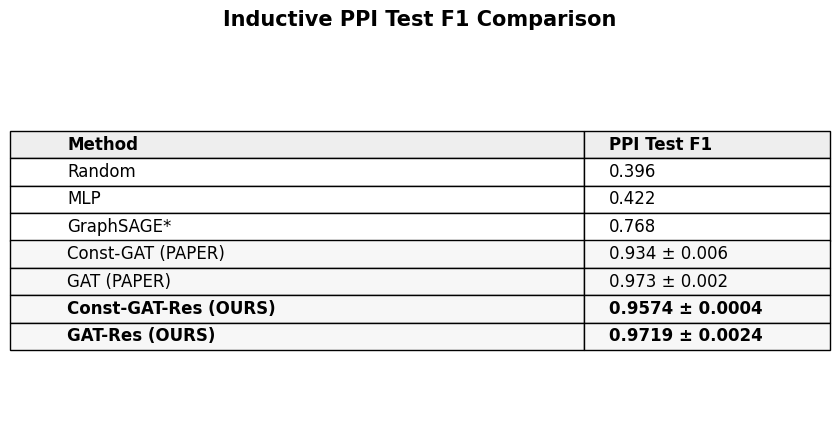

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import os

OUT_DIR = "/content/poster_graphs"
os.makedirs(OUT_DIR, exist_ok=True)

# FINAL VALUES (from your logs — DO NOT recompute)
const_mean, const_std = 0.9574, 0.0004
gat_mean, gat_std = 0.9719, 0.0024

table_data = [
    ["Random", "0.396"],
    ["MLP", "0.422"],
    ["GraphSAGE*", "0.768"],
    ["Const-GAT (PAPER)", "0.934 ± 0.006"],
    ["GAT (PAPER)", "0.973 ± 0.002"],
    ["Const-GAT-Res (OURS)", f"{const_mean:.4f} ± {const_std:.4f}"],
    ["GAT-Res (OURS)", f"{gat_mean:.4f} ± {gat_std:.4f}"],
]

df_table = pd.DataFrame(table_data, columns=["Method", "PPI Test F1"])

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.axis("off")

table = ax.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.7, 0.3]
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)

# Header styling
for col in range(2):
    table[(0, col)].set_text_props(weight="bold")
    table[(0, col)].set_facecolor("#eeeeee")

# Highlight paper + ours
for i, row in df_table.iterrows():
    if "PAPER" in row["Method"] or "OURS" in row["Method"]:
        for col in range(2):
            table[(i+1, col)].set_facecolor("#f7f7f7")

# Bold OURS
for i, row in df_table.iterrows():
    if "OURS" in row["Method"]:
        for col in range(2):
            table[(i+1, col)].set_text_props(weight="bold")

plt.title("Inductive PPI Test F1 Comparison", fontsize=15, weight="bold", pad=18)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ppi_results_table_clean.png", dpi=300, bbox_inches="tight")
plt.show()